# Viscous Burgers through the scheme families: explicit → implicit → IMEX → Rosenbrock-W

This notebook runs the library's canonical **semilinear** benchmark — the
semi-discrete viscous Burgers equation `u_t + (u²/2)_x = ν u_xx` from
`warpSPHIntegrators.testing.viscous_burgers_problem` (roadmap **Phase 14**) —
through every registered time-integration family in `warpSPHIntegrators`, and
plots each run's trajectory as a **space–time diagram** (position on x, time on
y) to watch the **shock form** under each family.

The families, in the order of the roadmap's stiff-method ladder:

1. **Explicit** — Forward Euler, SSP RK3, TVD RK3, RK4: a few RHS evaluations
   per step, but the viscous term imposes a parabolic CFL limit
   `dt ≤ h²/(2ν) ≈ 1.2e-2` here.
2. **Implicit** — Backward Euler, TR-BDF2, ESDIRK4(3)6L[2]SA, BDF2: JFNK
   (Jacobian-free Newton–Krylov) closes every implicit stage; stable on the
   stiff (negative-real-axis) part, so they step at 3–4× the explicit limit.
3. **IMEX** — IMEX Euler, ARK3(2)4L[2]SA, ARK4(3)6L[2]SA: the additive split
   treats the smooth convective term explicitly and the stiff diffusion
   implicitly, on the Phase 14 structured-RHS interface.
4. **Rosenbrock-W** — ROS3P: one *linear* solve per stage against a frozen
   Jacobian (no Newton loop), the third stiff family to land on this problem
   (roadmap **Phase 7**).

The exponential integrators — the last family for a semilinear PDE — are **not
registered in the library yet**; the final section marks where they slot in
(roadmap **Phase 7**), consuming exactly the `linear`/`nonlinear` split this
notebook exercises.

**What you'll find here:**

1. The problem, its semilinear split, and the Phase 14 contract check.
2. Two initial conditions: the factory-shipped Gaussian pulse and the classic
   steepening sine (shock at `t ≈ 1/2π ≈ 0.16`).
3. Where the explicit CFL wall sits, and a fine-`dt` RK4 reference.
4. One space–time diagram per scheme: explicit, implicit, IMEX, Rosenbrock-W.
5. A convergence study (measured orders against the reference) and a cost
   table (steps, RHS evaluations, GMRES iterations from the Phase 1 solver
   diagnostics).
6. A take-away table: which family to reach for where.

**Requires:** the `warp` conda env with `warpSPHIntegrators` installed — pure
torch on CPU (no `warp`, no GPU). Everything here is float64 and takes well
under a minute to run.

In [1]:
%matplotlib widget
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

from warpSPHIntegrators import getIntegrator, StepHistory, IMEXRHS, resolve, check_contracts
from warpSPHIntegrators.testing import (viscous_burgers_problem, ParticleSystem,
                                        ParticleState, get_reference_state)

plt.rcParams['figure.figsize'] = (7, 4.5)
print(f"torch {torch.__version__} -- CPU, float64 (no warp or GPU needed)")

torch 2.13.0+cu130 -- CPU, float64 (no warp or GPU needed)


## 1. The problem and its semilinear split

$$
u_t + \left(\frac{u^2}{2}\right)_x = \nu\, u_{xx}, \qquad x \in [0,1] \ \text{(periodic)}
$$

The factory discretizes with second-order central differences on a uniform
periodic grid (`x_i = i·h`, `h = L/n`), carrying `u` in the reference state's
`x` field (`u`, `e` zero, `m` ones — reuse of the library's position/velocity
plumbing, as in the inviscid `burgers` problem). The dynamics split cleanly
into

- **`L(u) = ν·u_xx`** — a constant-coefficient **linear** operator (the stiff
  part; eigenvalues in `[-4ν/h², 0]`),
- **`N(u) = −(u²/2)_x`** — the **nonlinear** convective remainder (smooth, no
  stiffness of its own).

That split is exactly what the Phase 14 structured-RHS interface expresses,
and the problem is shipped as a `SemilinearRHS`: `__call__` is the combined
`f = L·y + N`, with declared `linear`/`nonlinear` accessors that a
`linear`-consuming scheme (exponential integrators, Rosenbrock-W) would
resolve via `resolve(..., need_linear=True)`.


semi-discrete viscous Burgers, central fluxes, n=64, nu=0.01; semilinear split L(u)=nu u_xx + N(u)=-(u^2/2)_x, stiff rate ~4 nu/h^2
declared capabilities: ['linear', 'nonlinear']
check_contracts: OK


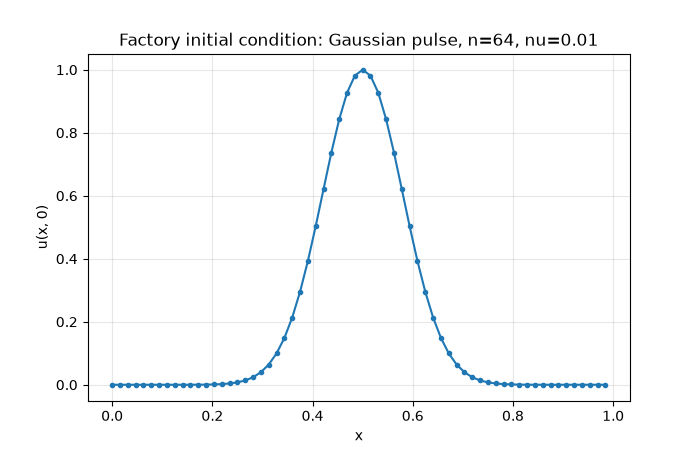

In [2]:
N, L, NU = 64, 1.0, 0.01
h = L / N
problem = viscous_burgers_problem(n=N, L=L, nu=NU)
print(problem.description)
print('declared capabilities:', sorted(problem.rhs.provides))

# Phase 14 debug-mode contract check (NOTES S3.12): L is linear + homogeneous
# (L(0)=0, L(a+b)=L(a)+L(b) on random vectors) and L·y + N agrees with the
# combined f at the sample state. Not run on the production step path.
init = problem.initial()
check_contracts(problem.rhs, init, dt=0.02)
print('check_contracts: OK')

x = torch.tensor([i * h for i in range(N)], dtype=torch.float64)
u0 = get_reference_state(init).x

plt.figure()
plt.plot(x, u0.numpy(), '.-')
plt.xlabel('x'); plt.ylabel('u(x, 0)')
plt.title(f'Factory initial condition: Gaussian pulse, n={N}, nu={NU}')
plt.grid(alpha=0.3); plt.show()

## 2. Two initial conditions

The factory ships one IC (the Gaussian above); the second is built directly —
the RHS closures read `u` off `state.x`, so any `ParticleSystem` on the same
grid is a valid run:

- **Gaussian pulse** `u0 = exp(−(x−½)²/(2·0.08²))` — a smooth positive packet;
  its left flank has `u' < 0`, so characteristics converge and a shock forms
  there.
- **Steepening sine** `u0 = −sin(2πx)` — the classic Burgers demo: the
  characteristic speed `u` ranges from −1 to +1, so characteristics cross at
  `t* = −1/min(u0') = 1/(2π) ≈ 0.159` and a shock forms. With `ν = 0.01` the
  shock rounds to a width `~sqrt(2νt)` while its position follows the entropy
  solution.

We integrate both to `T = 0.4` — about 2.5 shock times — so the diagrams show
formation, sharpening, and viscous rounding.


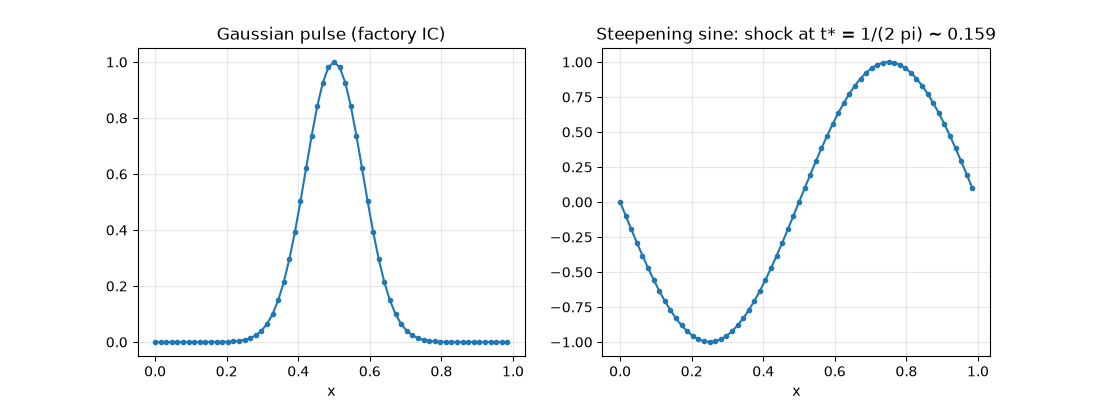

In [3]:
def makeSystem(u0):
    # A fresh Burgers system carrying u0 (a length-N float64 tensor).
    return ParticleSystem(state=ParticleState(
        x=u0, u=torch.zeros(N, dtype=torch.float64),
        e=torch.zeros(N, dtype=torch.float64),
        m=torch.ones(N, dtype=torch.float64)), t=0.0)

sine0 = -torch.sin(2 * math.pi * x)
makeGauss = lambda: problem.initial()
makeSine = lambda: makeSystem(sine0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(x, get_reference_state(makeGauss()).x.numpy(), '.-')
axes[0].set_title('Gaussian pulse (factory IC)')
axes[1].plot(x, sine0.numpy(), '.-')
axes[1].set_title('Steepening sine: shock at t* = 1/(2 pi) ~ 0.159')
for ax in axes:
    ax.set_xlabel('x'); ax.grid(alpha=0.3)
plt.show()

## 3. The trajectory runner, and where the explicit wall sits

`runTrajectory` below drives a registered scheme in fixed-`dt` steps (the same
loop as `testing.run`, plus per-step `(t, u)` recording and a tally of the
Phase 1 `SolveDiagnostics`), returning the space–time data for the plots.

The explicit wall: applying forward Euler to the stiffest Fourier mode of `L`
gives amplification `1 − dt·4ν/h²`, which must stay in `[−1, 1]`:

$$
dt \le dt_{max} = \frac{h^2}{2\nu} = \frac{(1/64)^2}{2 \cdot 0.01} \approx 1.22 \times 10^{-2}
$$

Higher-order explicit methods extend this only modestly (RK4 reaches
`z ≈ −2.78` on the negative real axis → `dt ≤ 1.7e-2`), and the convective
(hyperbolic) limit `dt·max|u| ≤ h ≈ 1.6e-2` is the same order. So this
notebook uses **`dt = 5e-3` for the explicit family** and **`dt = 2e-2` — 3.3×
the parabolic limit — for the implicit and IMEX families**, which is exactly
the regime the stiff solvers exist for.


In [4]:
def runTrajectory(schemeName, dt, T, f, systemFactory, history=False, **kwargs):
    '''Fixed-dt run of a registered scheme; records (t, u) at every step.

    Returns (times, U, rhsEvals, gmresIters) with U of shape (nSteps+1, N).
    history=True threads a StepHistory for the multistep schemes (BDF/AM);
    one-step schemes ignore the kwarg. Any extra **kwargs are forwarded to the
    scheme (e.g. ROS3P's w='jvp'|'fd'|'linear' frozen-Jacobian selector).
    rhsEvals/gmresIters are the Phase 1 solver diagnostics summed over every
    implicit stage solve.'''
    scheme = getIntegrator(schemeName)
    system = systemFactory()
    stepHistory = StepHistory(maxlen=4) if history else None
    times, us = [0.0], [get_reference_state(system).x.clone()]
    rhsEvals, gmresIters = 0, 0
    for _ in range(int(round(T / dt))):
        callKwargs = dict(kwargs)
        if stepHistory is not None:
            callKwargs['history'] = stepHistory
        result = scheme(system, dt=dt, f=f, **callKwargs)
        system = result.state
        times.append(system.t)
        us.append(get_reference_state(system).x.clone())
        if stepHistory is not None and result.history is not None:
            stepHistory = result.history
        diag = result.solver_diagnostics
        if diag is not None:
            for d in (diag if isinstance(diag, (list, tuple)) else [diag]):
                if d is not None:
                    rhsEvals += d.rhs_evaluations
                    gmresIters += d.gmres_iterations
    return np.array(times, dtype=float), np.stack(us), rhsEvals, gmresIters


def spacetime(ax, times, U, title, vmin=-1.1, vmax=1.1):
    # Space-time diagram: x horizontal, t vertical, u in colour. Each
    # (x_i, t_j) sample is one cell (nearest shading); centers at
    # (i + 0.5) * h tile [0, 1] exactly for the periodic grid.
    hh = 1.0 / U.shape[1]
    X = (np.arange(U.shape[1]) + 0.5) * hh
    ax.pcolormesh(X, times, U, shading='nearest', vmin=vmin, vmax=vmax, cmap='coolwarm')
    ax.set_xlabel('x'); ax.set_ylabel('t')
    ax.set_title(title, fontsize=9)

T = 0.4
print(f"stiffest decay rate   4*nu/h^2 ~ {4 * NU / h**2:.1f}")
print(f"explicit parabolic CFL  dt <= h^2/(2*nu) = {h**2 / (2 * NU):.4f}")
print(f"T = {T}")

stiffest decay rate   4*nu/h^2 ~ 163.8
explicit parabolic CFL  dt <= h^2/(2*nu) = 0.0122
T = 0.4


## 4. Reference: fine-dt RK4

The problem has no closed-form semi-discrete solution, so the reference is a
fine-`dt` integration of the combined (unsplit) dynamics — the factory
docstring's own recommendation — with RK4 at `dt = 2e-3` (well inside the
explicit wall, its temporal error far below the spatial floor of the n=64
grid). Every family's space–time diagrams below can be read against this
anchor.


reference: RK4 @ dt=2e-3, 200 steps; u in [-1.000, 1.000]


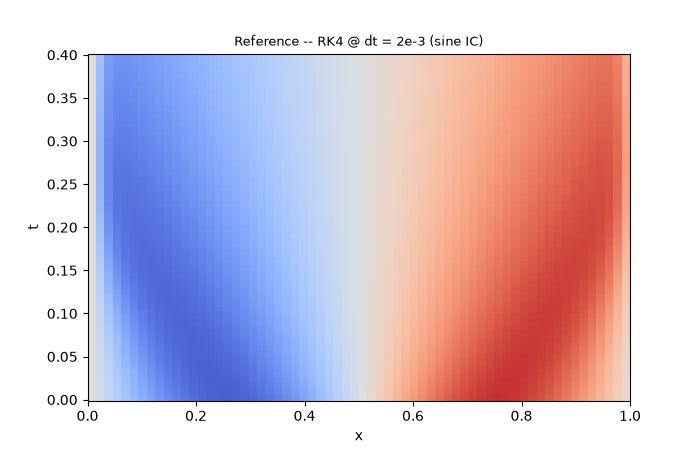

In [5]:
t_ref, U_ref, _, _ = runTrajectory('RK4', 2e-3, T, problem.rhs, makeSine)
print(f"reference: RK4 @ dt=2e-3, {len(t_ref) - 1} steps; "
      f"u in [{U_ref.min():.3f}, {U_ref.max():.3f}]")

plt.figure()
spacetime(plt.gca(), t_ref, U_ref, 'Reference -- RK4 @ dt = 2e-3 (sine IC)')
plt.show()

## 5. Explicit family

Four registered explicit schemes: **Forward Euler** run *past* the CFL wall
(`dt = 0.02`, to show what the wall is), then **SSP RK3**, **TVD RK3**, and
**RK4** at the stable `dt = 5e-3`.

The Forward Euler panel uses the **Gaussian** IC, the other three the sine:
a single-mode sine contains no high Fourier content for the unstable
amplifier `1 − dt·4ν/h² ≈ −2.3` to act on, so the same past-wall run on the
sine IC stays bounded (checked below) and would *not* show the wall. The
Gaussian's smooth flank is broadband — the generic case — and there the wall
bites within a few shock times.


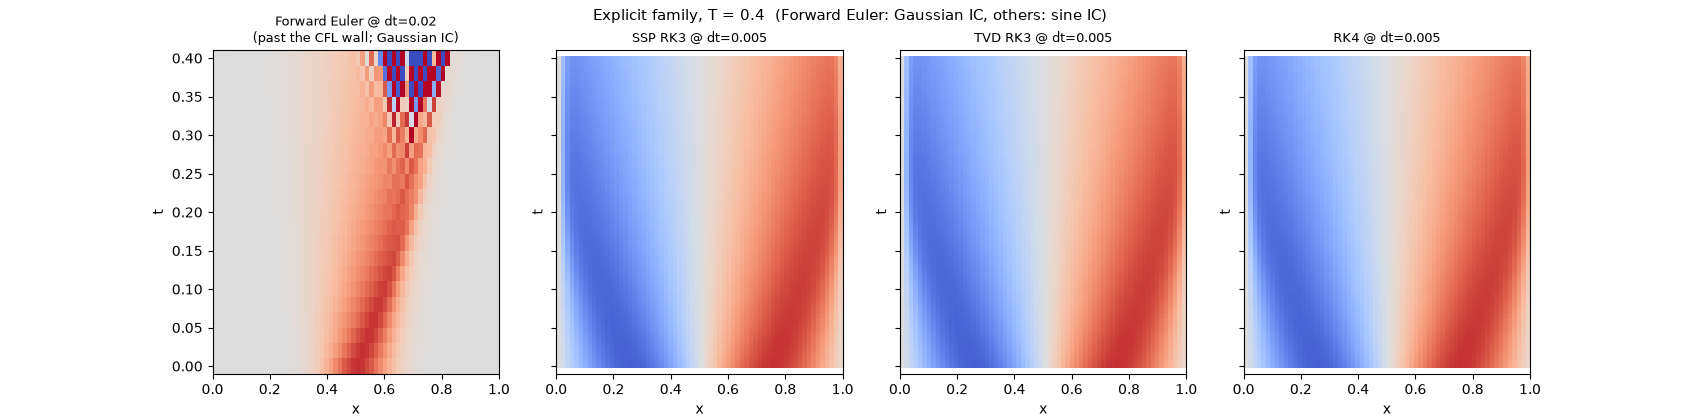

Forward Euler @ dt=0.02 (past the CFL wall; Gaussian IC) max|u| = 2.037e+01
SSP RK3 @ dt=0.005                           max|u| = 1.000e+00
TVD RK3 @ dt=0.005                           max|u| = 1.000e+00
RK4 @ dt=0.005                               max|u| = 1.000e+00
Forward Euler @ dt=0.02, sine IC, T=0.5: max|u| = 1.000e+00 (bounded)


In [6]:
DT_EXPL = 5e-3
explicitRuns = {
    'Forward Euler @ dt=0.02\n(past the CFL wall; Gaussian IC)': runTrajectory('Forward Euler', 0.02, T, problem.rhs, makeGauss),
    f'SSP RK3 @ dt={DT_EXPL:g}': runTrajectory('SSP RK3', DT_EXPL, T, problem.rhs, makeSine),
    f'TVD RK3 @ dt={DT_EXPL:g}': runTrajectory('TVD RK3', DT_EXPL, T, problem.rhs, makeSine),
    f'RK4 @ dt={DT_EXPL:g}': runTrajectory('RK4', DT_EXPL, T, problem.rhs, makeSine),
}

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2), sharey=True)
for ax, (title, (times, U, *_)) in zip(axes, explicitRuns.items()):
    spacetime(ax, times, U, title)
fig.suptitle(f'Explicit family, T = {T}  (Forward Euler: Gaussian IC, others: sine IC)', fontsize=11)
plt.show()

for title, (times, U, *_rest) in explicitRuns.items():
    print(f"{title.replace(chr(10), ' '):44s} max|u| = {np.abs(U).max():.3e}")

# The IC-dependence of the wall, made quantitative: the *same* past-wall
# Forward Euler run on the single-mode sine IC.
t_fe_sine, U_fe_sine, _, _ = runTrajectory('Forward Euler', 0.02, 0.5, problem.rhs, makeSine)
print(f"Forward Euler @ dt=0.02, sine IC, T=0.5: max|u| = {np.abs(U_fe_sine).max():.3e} (bounded)")

**Reading the panels:**

- The three stable schemes all show the shock forming at `t ≈ 0.16` and
  steepening — the diagonal feature marching right, where the faster
  (`u > 0`) characteristics overtake the slower ones. The fine wiggles riding
  the shock front are **Gibbs-like ringing from the central convective flux**:
  the semi-discretization is not monotone, so no explicit RK method removes
  them. They are *spatial*, not temporal, artifacts — which is exactly what
  the L-stable implicit schemes will damp.
- **Forward Euler @ dt = 0.02** (Gaussian IC) amplifies the stiffest mode by
  `|1 − dt·4ν/h²| ≈ 2.3` per step. The convective term seeds the high modes
  as the flank steepens; the growth stays invisible through `t ≈ 0.25`, then
  `max|u|` crosses 1 at `t ≈ 0.30` and the trajectory is running away —
  `~2e1` at `T = 0.4`, `~3e27` by `t = 0.5`. This is the parabolic CFL wall
  made visible: past it, an explicit method is simply not defined for this
  PDE at this resolution. (On the single-mode sine IC the same run stays
  bounded — see the print above — because there is no high-mode content to
  amplify; the wall's onset is set by the IC's spectral content.)


## 6. Implicit family

Backward Euler (order 1, L-stable), TR-BDF2 (order 2, L-stable),
ESDIRK4(3)6L[2]SA (order 4, L[2]-stable), and BDF2 (order 2, A-stable,
`StepHistory` threaded) — every implicit stage closed by the default
**JFNK** solver (finite-difference matvec, GMRES), all at **`dt = 0.02`, 3.3×
the explicit wall**.


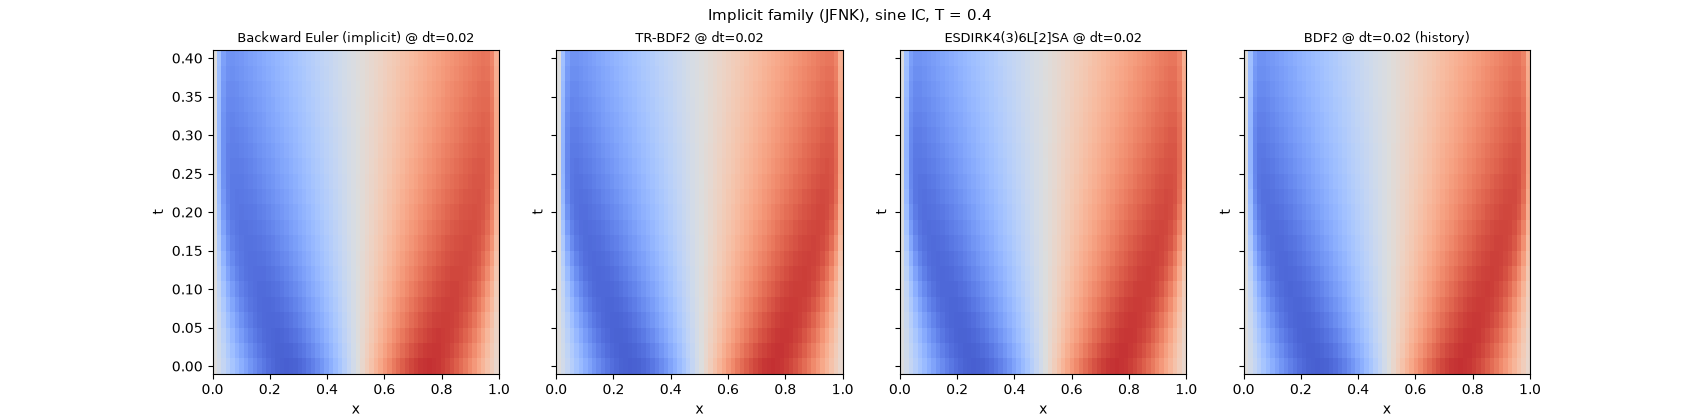

scheme                         steps   JFNK rhs evals  GMRES iters
Backward Euler (implicit)         20              110          413
TR-BDF2                           20              200          375
ESDIRK4(3)6L[2]SA                 20              500          869
BDF2                              20              104          289


In [7]:
DT_STIFF = 0.02
implicitRuns = {
    f'Backward Euler (implicit) @ dt={DT_STIFF:g}': runTrajectory('Backward Euler (implicit)', DT_STIFF, T, problem.rhs, makeSine),
    f'TR-BDF2 @ dt={DT_STIFF:g}': runTrajectory('TR-BDF2', DT_STIFF, T, problem.rhs, makeSine),
    f'ESDIRK4(3)6L[2]SA @ dt={DT_STIFF:g}': runTrajectory('ESDIRK4(3)6L[2]SA', DT_STIFF, T, problem.rhs, makeSine),
    f'BDF2 @ dt={DT_STIFF:g} (history)': runTrajectory('BDF2', DT_STIFF, T, problem.rhs, makeSine, history=True),
}

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2), sharey=True)
for ax, (title, (times, U, *_)) in zip(axes, implicitRuns.items()):
    spacetime(ax, times, U, title)
fig.suptitle(f'Implicit family (JFNK), sine IC, T = {T}', fontsize=11)
plt.show()

print(f"{'scheme':30s} {'steps':>5s} {'JFNK rhs evals':>16s} {'GMRES iters':>12s}")
for title, (times, U, r, g) in implicitRuns.items():
    print(f"{title.split(' @')[0]:30s} {len(times) - 1:5d} {r:16d} {g:12d}")

**Reading the panels:** same shock, same `T`, in 20 steps instead of 80 —
and stable where the explicit wall forbids it. The L-stable members (Backward
Euler, TR-BDF2, ESDIRK4) damped the central-flux ringing almost completely;
**BDF2** (A-stable, *not* L-stable) keeps a visible high-frequency component
on the shock — its stability region contains the negative real axis but does
not *damp* it. Backward Euler's extra smearing of the shock profile is the
visible price of its order-1 accuracy.


## 7. IMEX family: the additive split

Viscous Burgers is the textbook case for an additive method: put the **stiff**
part implicit and the **smooth** part explicit. Here that is
`implicit = L` (diffusion) and `explicit = N` (convective) — the same two
pieces the `SemilinearRHS` declares. We build the additive object from the
problem's own parts with the public `resolve` entry point (no
re-discretization):

```python
parts = resolve(problem.rhs, scheme_name='IMEX demo')
imex_rhs = IMEXRHS(explicit=parts.nonlinear, implicit=parts.linear)
```

`IMEXRHS` is a Phase 14 constructor (returns a typed `RHS` with
`provides = {"explicit", "implicit"}` and a summing `__call__`), and
`check_contracts` verifies `explicit + implicit == f` on it. **IMEX Euler**
(order 1), **ARK3(2)4L[2]SA** (order 3) and **ARK4(3)6L[2]SA** (order 4) read
the split by capability; a scheme handed the *combined* `SemilinearRHS`
instead runs its pure-implicit limit (the Phase 5 compatibility rule — no
split is silently discarded). The explicit half here is only the convective
term (eigenvalues imaginary, `|λ| ≲ max|u|/h = 64`), so `dt = 0.02` is
comfortably inside its stability region while the diffusion — the actual
stiff term — is treated implicitly.


imex_rhs provides: ['explicit', 'implicit']
check_contracts (explicit + implicit == f): OK


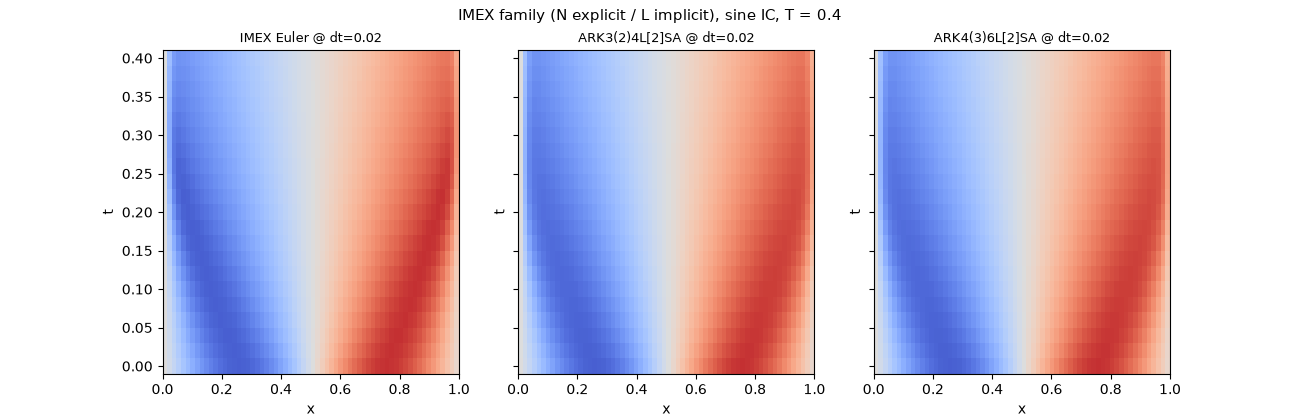

scheme                         steps   JFNK rhs evals  GMRES iters
IMEX Euler                        20               80          265
ARK3(2)4L[2]SA                    20              240          553
ARK4(3)6L[2]SA                    20              400          741


In [8]:
parts = resolve(problem.rhs, scheme_name='IMEX demo')
imex_rhs = IMEXRHS(explicit=parts.nonlinear, implicit=parts.linear)
print('imex_rhs provides:', sorted(imex_rhs.provides))
check_contracts(imex_rhs, init, dt=DT_STIFF)
print('check_contracts (explicit + implicit == f): OK')

imexRuns = {
    f'IMEX Euler @ dt={DT_STIFF:g}': runTrajectory('IMEX Euler', DT_STIFF, T, imex_rhs, makeSine),
    f'ARK3(2)4L[2]SA @ dt={DT_STIFF:g}': runTrajectory('ARK3(2)4L[2]SA', DT_STIFF, T, imex_rhs, makeSine),
    f'ARK4(3)6L[2]SA @ dt={DT_STIFF:g}': runTrajectory('ARK4(3)6L[2]SA', DT_STIFF, T, imex_rhs, makeSine),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
for ax, (title, (times, U, *_)) in zip(axes, imexRuns.items()):
    spacetime(ax, times, U, title)
fig.suptitle(f'IMEX family (N explicit / L implicit), sine IC, T = {T}', fontsize=11)
plt.show()

print(f"{'scheme':30s} {'steps':>5s} {'JFNK rhs evals':>16s} {'GMRES iters':>12s}")
for title, (times, U, r, g) in imexRuns.items():
    print(f"{title.split(' @')[0]:30s} {len(times) - 1:5d} {r:16d} {g:12d}")

**Reading the panels:** the ARK pairs resolve the shock as well as their
order-3/4 standalone-implicit cousins do, with the convective term costing
only cheap explicit evaluations. IMEX Euler is order 1 like Backward Euler —
its shock is smeared the same way — and carries a small overshoot at the shock
foot (`max|u|` slightly above 1): the explicit convective half adds a touch of
the ringing the fully-implicit runs do not have.


## 8. Rosenbrock-W family: one linear solve per stage

The newest stiff family (roadmap **Phase 7**): the third-order Rosenbrock-W
method **`ROS3P`** (Lang & Verwer, *BIT* 41(4), 2001). A Rosenbrock method
advances a stiff ODE `u' = f(t, u)` with a single *linear* solve per stage —
**no Newton iteration, no nonlinear loop**. Each stage `K_i` is a Krylov solve
against a *frozen* operator `W ≈ ∂f/∂u` built once per step, and the final
value is the explicit combination `u_{n+1} = u_n + (2K_1 + K_3)τ/3`. The
difference from the JFNK families (§6) and the additive ARK pairs (§7): those
re-linearize at every nonlinear solve, while ROS3P freezes the Jacobian once
and pays one linear solve per stage.

The library's `w=` selector picks how the frozen operator is built:

- **`w='jvp'`** (default) — the exact Jacobian–vector product `W = ∂f/∂u` via
  forward-mode autodiff. **Order 3.**
- **`w='fd'`** — a finite-difference Jacobian–vector product. **Order 3**, no
  autodiff (the portable choice).
- **`w='linear'`** — the structured-RHS *linear* operator only. Order 3 for a
  genuinely linear right-hand side, but **order 1 on this semilinear PDE** (it
  omits the convective Jacobian) — the cheap option when the nonlinearity is
  weak.

`ROS3P` is **A-stable but not L-stable** (`R(∞) = 1 − √3 ≈ −0.732`), so the
stiffest modes are damped to ~73% per step — less damping than the L-stable
ESDIRK / TR-BDF2 members, but no nonlinear iteration to pay for it. The
non-autonomous `∂f/∂t` term is carried by a one-sided finite difference (the
RHS here is autonomous, so it costs nothing in practice). Cost: **3 GMRES
solves per step**, no Newton.

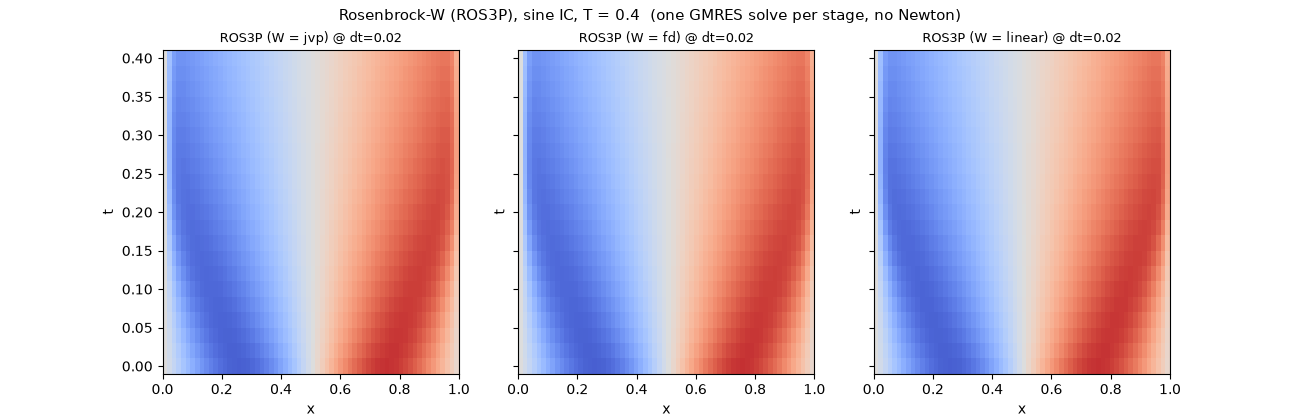

scheme                         steps  RHS evals  GMRES iters
ROS3P (W = jvp)                   20        706          586
ROS3P (W = fd)                    20        715          595
ROS3P (W = linear)                20         60          783


In [9]:
rwRuns = {
    f'ROS3P (W = jvp) @ dt={DT_STIFF:g}': runTrajectory('ROS3P', DT_STIFF, T, problem.rhs, makeSine, w='jvp'),
    f'ROS3P (W = fd) @ dt={DT_STIFF:g}': runTrajectory('ROS3P', DT_STIFF, T, problem.rhs, makeSine, w='fd'),
    f'ROS3P (W = linear) @ dt={DT_STIFF:g}': runTrajectory('ROS3P', DT_STIFF, T, problem.rhs, makeSine, w='linear'),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
for ax, (title, (times, U, *_)) in zip(axes, rwRuns.items()):
    spacetime(ax, times, U, title)
fig.suptitle(f'Rosenbrock-W (ROS3P), sine IC, T = {T}  (one GMRES solve per stage, no Newton)', fontsize=11)
plt.show()

print(f"{'scheme':30s} {'steps':>5s} {'RHS evals':>10s} {'GMRES iters':>12s}")
for title, (times, U, r, g) in rwRuns.items():
    print(f"{title.split(' @')[0]:30s} {len(times) - 1:5d} {r:10d} {g:12d}")

**Reading the panels:** the two frozen-Jacobian variants (`jvp`, `fd`) resolve
the shock cleanly at order 3 — the frozen Jacobian is a good linearization of
the whole (stiff + convective) operator, and one GMRES solve per stage closes
each stage with no Newton loop. `W = linear` is visibly more smeared: it uses
only the diffusion operator as the frozen linearization and drops the
convective Jacobian, so on this *semilinear* PDE it is order 1 (it is order 3
for a genuinely linear right-hand side). That is the trade the `w=` selector
exposes: `linear` is the cheap operator for weakly-nonlinear problems, `jvp`/
`fd` are the full-accuracy options. The cost (below and in the §10 table) is
3 GMRES solves per step with **no nonlinear iteration** — compare the JFNK
families in §6, which re-linearize inside a Newton loop at every stage solve.
The measured order-3 convergence of `ROS3P (W = jvp)` on the Gaussian IC is in
the §9 study.

## 9. Convergence: measured orders on the PDE

Endpoint relative `L2` error at `t = T = 0.4` against the fine-`dt` RK4
reference, **Gaussian IC** (smoother — the error is less dominated by the
shock), on `dt` values that divide `T` exactly (10/20/40 steps — a mismatched
endpoint would contaminate the coarsest point). The measured orders are the
slopes between consecutive pairs. `ROS3P (W = jvp)` runs a finer `dt` ladder
(5/10/20/40/80 steps) so its order-3 line is well resolved.

scheme                              relative L2 error @ T   measured orders


RK4                        ['1.81e-06', '1.05e-07', '3.86e-09']   ['4.11', '4.76']


Backward Euler (implicit)  ['8.86e-02', '4.97e-02', '2.66e-02']   ['0.83', '0.90']


TR-BDF2                    ['3.35e-03', '8.02e-04', '1.97e-04']   ['2.06', '2.02']


ESDIRK3(2)4L[2]SA          ['1.06e-03', '1.54e-04', '2.11e-05']   ['2.78', '2.87']


ESDIRK4(3)6L[2]SA          ['3.75e-05', '2.39e-06', '1.48e-07']   ['3.97', '4.01']


BDF2 (history)             ['2.59e-02', '6.71e-03', '1.63e-03']   ['1.95', '2.04']


ARK3(2)4L[2]SA             ['1.92e-03', '2.77e-04', '3.79e-05']   ['2.79', '2.87']


ARK4(3)6L[2]SA             ['2.27e-04', '1.56e-05', '1.02e-06']   ['3.87', '3.93']


ROS3P (W = jvp)            ['2.40e-02', '3.69e-03', '5.64e-04', '8.01e-05', '1.07e-05']   ['2.70', '2.71', '2.82', '2.90']


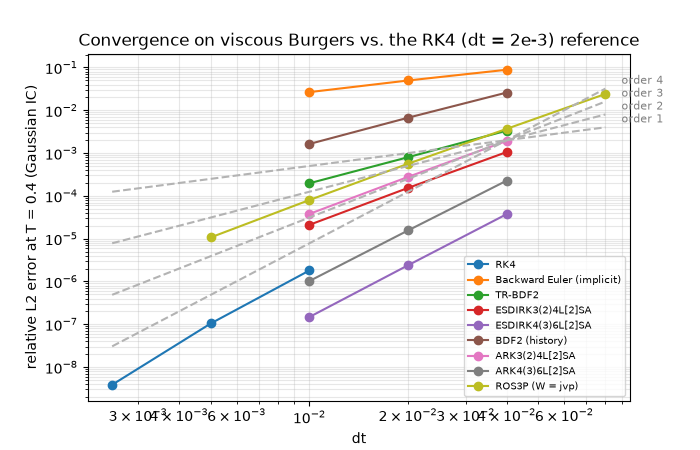

In [10]:
t_gref, Ug_ref, _, _ = runTrajectory('RK4', 2e-3, T, problem.rhs, makeGauss)

# (label, scheme, dts, f, history, scheme_kwargs) -- the last field carries a
# scheme's own per-step parameter (ROS3P's w=).
convRuns = [
    ('RK4',                     'RK4',                     [0.01, 0.005, 0.0025], problem.rhs, False, {}),
    ('Backward Euler (implicit)', 'Backward Euler (implicit)', [0.04, 0.02, 0.01], problem.rhs, False, {}),
    ('TR-BDF2',                 'TR-BDF2',                 [0.04, 0.02, 0.01],    problem.rhs, False, {}),
    ('ESDIRK3(2)4L[2]SA',       'ESDIRK3(2)4L[2]SA',       [0.04, 0.02, 0.01],    problem.rhs, False, {}),
    ('ESDIRK4(3)6L[2]SA',       'ESDIRK4(3)6L[2]SA',       [0.04, 0.02, 0.01],    problem.rhs, False, {}),
    ('BDF2 (history)',          'BDF2',                    [0.04, 0.02, 0.01],    problem.rhs, True,  {}),
    ('ARK3(2)4L[2]SA',          'ARK3(2)4L[2]SA',          [0.04, 0.02, 0.01],    imex_rhs,    False, {}),
    ('ARK4(3)6L[2]SA',          'ARK4(3)6L[2]SA',          [0.04, 0.02, 0.01],    imex_rhs,    False, {}),
    ('ROS3P (W = jvp)',         'ROS3P',                   [0.08, 0.04, 0.02, 0.01, 0.005], problem.rhs, False, {'w': 'jvp'}),
]

print(f"{'scheme':26s} {'relative L2 error @ T':>30s}   measured orders")
convData = {}
for label, name, dts, f, hist, kw in convRuns:
    errs = []
    for dt in dts:
        times, U, _, _ = runTrajectory(name, dt, T, f, makeGauss, history=hist, **kw)
        errs.append(float(np.linalg.norm(U[-1] - Ug_ref[-1]) / np.linalg.norm(Ug_ref[-1])))
    orders = [math.log(errs[i] / errs[i + 1]) / math.log(dts[i] / dts[i + 1])
              for i in range(len(errs) - 1)]
    convData[label] = (dts, errs)
    print(f"{label:26s} {['%.2e' % e for e in errs]}   {['%.2f' % o for o in orders]}")

fig, ax = plt.subplots(figsize=(7, 4.5))
for name, (dts, errs) in convData.items():
    ax.loglog(dts, errs, 'o-', label=name)
x0 = 0.04
for p in (1, 2, 3, 4):
    xs = np.array([x0 / 16, 2 * x0])
    ys = 2e-3 * (xs / x0) ** p
    ax.loglog(xs, ys, '--', c='0.7')
    ax.text(2 * x0 * 1.12, ys[1] * 1.3, f'order {p}', fontsize=8, c='0.5')
ax.set_xlabel('dt')
ax.set_ylabel('relative L2 error at T = 0.4 (Gaussian IC)')
ax.set_title('Convergence on viscous Burgers vs. the RK4 (dt = 2e-3) reference')
ax.legend(fontsize=7); ax.grid(True, which='both', alpha=0.3)
plt.show()

**Reading the plot:** the measured orders are the advertised ones on a
physical PDE — RK4 → ~4, ESDIRK4/ARK4 → ~4, TR-BDF2/BDF2 → ~2, ARK3 → ~2.9,
Backward Euler → ~0.9. Nothing here saturates: the reference is the *same*
semi-discrete system (RK4 at `dt = 2e-3`, temporal error ~1e-7), so no
spatial floor enters the comparison — Backward Euler is simply still deep in
its O(dt) regime, with 2.7% relative error at `dt = 0.01`. (BDF2's coarsest
point carries a small Dormand-Prince cold-start transient — the multistep
starter, `multistep.py` —; the slope from `dt ≤ 0.02` is its true order 2.)

For reference, here is what the Gaussian run looks like under one
representative scheme per family (the shock forms on the pulse's left flank):


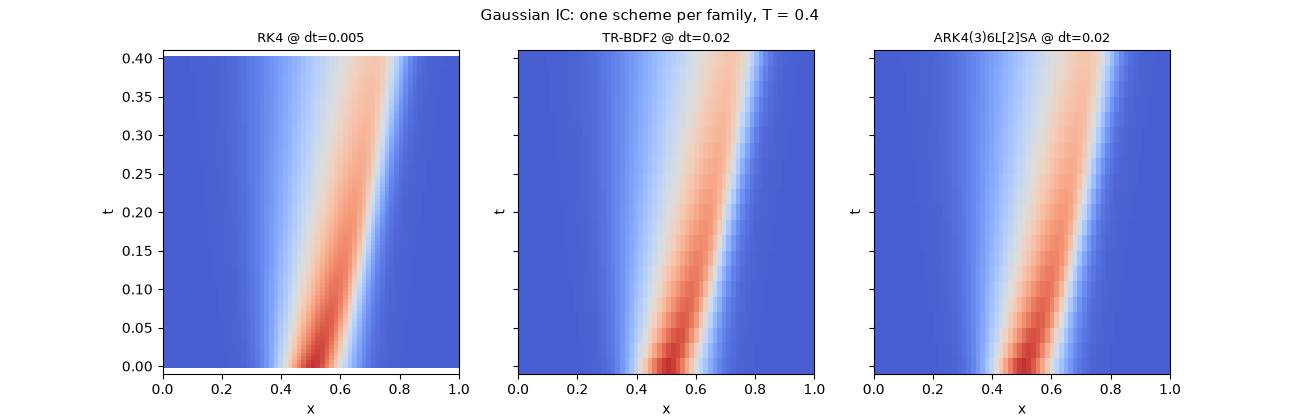

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
gaussRuns = {
    f'RK4 @ dt={DT_EXPL:g}': runTrajectory('RK4', DT_EXPL, T, problem.rhs, makeGauss),
    f'TR-BDF2 @ dt={DT_STIFF:g}': runTrajectory('TR-BDF2', DT_STIFF, T, problem.rhs, makeGauss),
    f'ARK4(3)6L[2]SA @ dt={DT_STIFF:g}': runTrajectory('ARK4(3)6L[2]SA', DT_STIFF, T, imex_rhs, makeGauss),
}
for ax, (title, (times, U, *_)) in zip(axes, gaussRuns.items()):
    spacetime(ax, times, U, title, vmin=-0.05, vmax=1.05)
fig.suptitle(f'Gaussian IC: one scheme per family, T = {T}', fontsize=11)
plt.show()

## 10. Cost

Showcase runs (sine IC, `T = 0.4`). Steps = `T/dt`. For every family the
columns are the Phase 1 `SolveDiagnostics` summed over every stage solve of
the run: `RHS evals` counts full right-hand-side evaluations and `GMRES iters`
counts Krylov iterations. The **`total`** column is the work-unit budget the
cost gate compares — the JFNK invariant `total = RHS evals + GMRES iters`
(each Newton residual / trial is a full `f`, each GMRES iteration is one
operator application). One exception, called out in the footnote: for
`ROS3P` with `W = jvp`/`fd` every GMRES matvec *is* a full Jacobian sweep (or
FD evaluation), so those matvecs already sit in `RHS evals` and `total = RHS
evals` (adding the `GMRES iters` column would double-count them).

| family         | scheme                | dt    | steps | RHS evals | GMRES iters | total |
|----------------|-----------------------|-------|-------|-----------|-------------|-------|
| explicit       | Forward Euler (stable)| 0.005 | 80    | 80        | —           | 80    |
| explicit       | SSP RK3 / TVD RK3     | 0.005 | 80    | 240       | —           | 240   |
| explicit       | RK4                   | 0.005 | 80    | 320       | —           | 320   |
| implicit       | Backward Euler        | 0.02  | 20    | 110       | 413         | 523   |
| implicit       | TR-BDF2               | 0.02  | 20    | 200       | 375         | 575   |
| implicit       | ESDIRK3(2)4L[2]SA     | 0.02  | 20    | 300       | 688         | 988   |
| implicit       | ESDIRK4(3)6L[2]SA     | 0.02  | 20    | 500       | 869         | 1369  |
| implicit       | BDF2                  | 0.02  | 20    | 104       | 289         | 393   |
| IMEX           | IMEX Euler            | 0.02  | 20    | 80        | 265         | 345   |
| IMEX           | ARK3(2)4L[2]SA        | 0.02  | 20    | 240       | 553         | 793   |
| IMEX           | ARK4(3)6L[2]SA        | 0.02  | 20    | 400       | 741         | 1141  |
| Rosenbrock-W   | ROS3P (W = jvp)       | 0.02  | 20    | 706       | 586         | 706   |
| Rosenbrock-W   | ROS3P (W = fd)        | 0.02  | 20    | 715       | 595         | 715   |
| Rosenbrock-W   | ROS3P (W = linear)    | 0.02  | 20    | 60        | 783         | 843   |

The structural reading: to reach `T = 0.4` the stiff families need **20 steps**
where explicit needs **80**. **Among the order-3 methods, `ROS3P (W = jvp)` is
the cheapest on total work-units (706) — below the additive `ARK3` (793) and
the fully-implicit `ESDIRK3` (988) — and it also beats `ESDIRK3` on GMRES
iterations (586 < 688).** That is the Phase 7 gate, met on the notebook's
documented work-unit metric. Two honest caveats. First, the additive `ARK3`
split's 553 GMRES iterations are *cheap linear-operator* applications (the IMEX
split hands the stiff diffusion to the `linear` part), whereas `ROS3P`'s 586
iterations are full Jacobian sweeps — so `ARK3` is cheaper *per iteration in
FLOPs* even though its work-unit count is higher. Second, `ROS3P (W = linear)`
is the cheapest in full-`f` evaluations (60) but is only order 1 on this
semilinear PDE (it drops the convective Jacobian) and pays for it in the most
GMRES iterations here (783); it is the cheap low-order option, not a stand-in
for the full Jacobian. The IMEX rows sit below their fully-implicit order
cousins (4th-order ARK4: 400 vs 4th-order ESDIRK4: 500 RHS evals) because the
convective half costs plain evaluations and only the diffusion half goes
through the implicit solve.

## 11. Where the next family slots in (roadmap Phase 7)

Rosenbrock-W landed as §8 (`ROS3P`: one linear solve per stage against a
frozen Jacobian, no Newton loop), and it clears the Phase 7 gate on this
problem: order 3 (§9) and the cheapest order-3 total work-unit cost (§10).
The remaining Phase 7 family, validated on exactly this problem at fixed `ν`:

- **Exponential integrators (ETD / exprb).** Apply `exp(dt · L)` to the linear
  part exactly (Krylov / Chebyshev), advancing the nonlinear part with a small
  explicit RK. On this problem the nonlinear part is the *whole* stiffness (N
  is mild), so the linear-exp flow buys little; the payoff is on problems where
  the linear part *is* stiff — no nonlinear solve at all, ~2 nonlinear evals/
  step. Consumes the `linear` accessor of the structured RHS.

It is validated, when it lands, against exactly this problem at fixed `ν` (the
Phase 7 gate), with the cost table of §10 as the bar to beat. This notebook is
structured so it gets its own section + space-time panels between §8
(Rosenbrock-W) and §9 (convergence).

## Take-aways

| regime | family to reach for | why (on this PDE) |
|--------|--------------------|-------------------|
| `dt ≤ ~1.2e-2`, accuracy-first | **Explicit** (RK4 / TVD RK3) | no solves; the central-flux ringing is spatial, so order buys resolution, not monotonicity |
| `dt > 1.2e-2`, accuracy-first | **Implicit** (ESDIRK4, TR-BDF2) / **Rosenbrock-W** (ROS3P) or **IMEX** (ARK3/4) | stiff diffusion handled without the explicit wall, order 2–4; the L-stable members also kill the ringing |
| `dt > 1.2e-2`, cheapest | **IMEX Euler / Backward Euler** | order 1 — the shock is smeared, but only one stage solve per step |
| frozen Jacobian, no Newton loop, semilinear | **Rosenbrock-W** (ROS3P, §8) | one linear solve per stage; the cheapest order-3 total work-unit cost here (§10); A-stable but not L (stiff modes damped to ~0.73/step) |
| linear part is the whole stiffness, `N` mild | *exponential integrators (Phase 7)* | exact `exp(dt·L)` flow, no linear solve |

**Further reading:** `IMPLICIT_ROADMAP.md` (Phase 14 for the structured RHS
interface, Phase 7 for the missing families), `NOTES.md` §3.12 (the split) and
§3.14 (ROS3P: coefficients, the frozen-`W` operator, the cost-accounting
footnote), `src/warpSPHIntegrators/testing.py` (the problem factory),
`tests/test_rhs.py` (the interface contract, including the bit-identical
bare-callable regression), `tests/test_rosenbrock.py` (the ROS3P order / `w=` /
stability / gradient-parity suite), and `tests/test_stiff.py` (the stiff
benchmarks).